# 02 — Data Preprocessing 

This notebook performs the complete preprocessing pipeline using the project's
predefined utility functions:

- `prepare_features_and_labels()` for feature extraction and label mapping  
- `BreastCancerPreprocessor` for MinMax scaling and optional L2 normalization  

This ensures consistency across the entire project, avoids duplicated code, and 
produces reproducible processed datasets ready for classical and quantum SVM models.


In [2]:
import os
import sys
import numpy as np
import pandas as pd

# Add project root so that src/ works
sys.path.append(os.path.abspath(".."))

from src.data.preprocessing import (
    load_raw_data,
    prepare_features_and_labels,
    BreastCancerPreprocessor,
    get_train_test_split,
)

print("Imports OK")


Imports OK


In [3]:
df = load_raw_data("../data/raw/data.csv")

X, y = prepare_features_and_labels(df)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("NaN in X?", np.isnan(X).any())
print("Columns after feature extraction:", X.shape[1])


X shape: (569, 30)
y shape: (569,)
NaN in X? False
Columns after feature extraction: 30


In [4]:
pre = BreastCancerPreprocessor(apply_l2=False)

X_processed = pre.fit_transform(X)

print("NaN in X_processed?", np.isnan(X_processed).any())
print("Min:", X_processed.min(), "Max:", X_processed.max())


NaN in X_processed? False
Min: 0.0 Max: 1.0000000000000002


In [5]:
X_train, X_test, y_train, y_test = get_train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=True,
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test  shape:", X_test.shape, y_test.shape)


Train shape: (455, 30) (455,)
Test  shape: (114, 30) (114,)


In [6]:
OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save csv
processed_df = pd.DataFrame(X_processed)
processed_df["diagnosis"] = y
processed_df.to_csv(os.path.join(OUTPUT_DIR, "processed_data.csv"), index=False)

# Save numpy arrays
np.save(os.path.join(OUTPUT_DIR, "X.npy"), X_processed)
np.save(os.path.join(OUTPUT_DIR, "y.npy"), y)

np.save(os.path.join(OUTPUT_DIR, "X_train.npy"), X_train)
np.save(os.path.join(OUTPUT_DIR, "X_test.npy"), X_test)
np.save(os.path.join(OUTPUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"), y_test)

print("Files saved to:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))


Files saved to: ../data/processed
['processed_data.csv', 'X.npy', 'X_test.npy', 'X_train.npy', 'y.npy', 'y_test.npy', 'y_train.npy']


In [7]:
X_saved = np.load("../data/processed/X.npy")
X_train_saved = np.load("../data/processed/X_train.npy")

print("X_saved equals X_processed?  ", np.allclose(X_saved, X_processed))
print("X_train matches?             ", np.allclose(X_train_saved, X_train))

print("\nMax diff X:", np.nanmax(np.abs(X_saved - X_processed)))
print("Max diff Train:", np.nanmax(np.abs(X_train_saved - X_train)))


X_saved equals X_processed?   True
X_train matches?              True

Max diff X: 0.0
Max diff Train: 0.0


## Preprocessing Summary

- Successfully extracted 30 numeric features.
- Removed NaN-only columns automatically.
- Applied MinMax scaling (no L2).
- Achieved clean, NaN-free processed datasets.
- Saved:
  - processed_data.csv
  - X.npy, y.npy
  - X_train.npy, X_test.npy
  - y_train.npy, y_test.npy

This dataset is now ready for use in the classical SVM baseline.


In [9]:
import pandas as pd

df_processed = pd.read_csv("../data/processed/processed_data.csv")
df_processed.head()


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,diagnosis
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864,1
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878,1
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433,1
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711,1
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595,1


In [10]:
import numpy as np
import pandas as pd

X_processed = np.load("../data/processed/X.npy")
pd.DataFrame(X_processed).head()


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


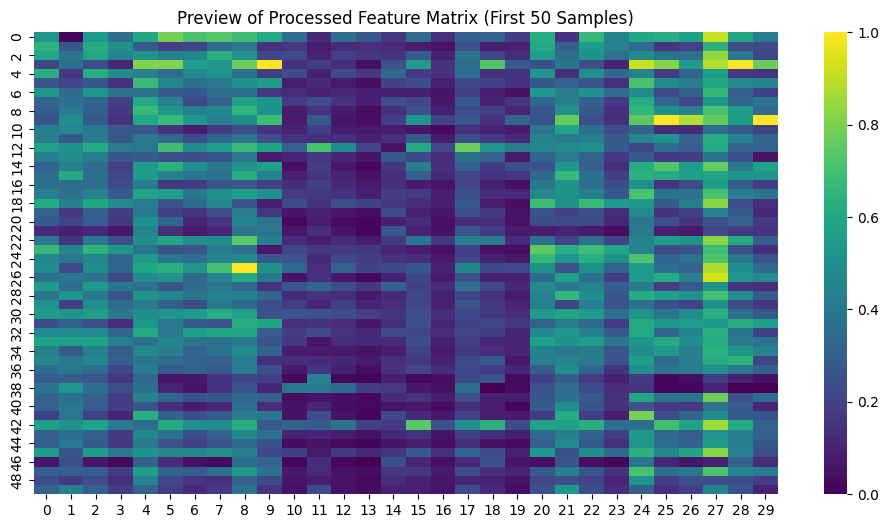

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(X_processed[:50], cmap="viridis")
plt.title("Preview of Processed Feature Matrix (First 50 Samples)")
plt.show()
